In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

import joblib


In [2]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Stopwords Loaded Successfully")

Stopwords Loaded Successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
from google.colab import files

uploaded = files.upload()


Saving spam.csv to spam (2).csv


In [6]:
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df = df[["v1", "v2"]]

df.columns = [
    "label",
    "message"
]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print(df.shape)

df.info()

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
df.isnull().sum()


,0
label,0
message,0


In [10]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 403


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
min_cost_price,0
max_cost_price,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0


In [11]:
df = df.drop_duplicates()

print(df.shape)

(5169, 2)


In [12]:
df["label"].value_counts()

,count
label,
ham,4516
spam,653


In [13]:
(df["label"].value_counts(normalize=True))*100

,proportion
label,
ham,87.366996
spam,12.633004


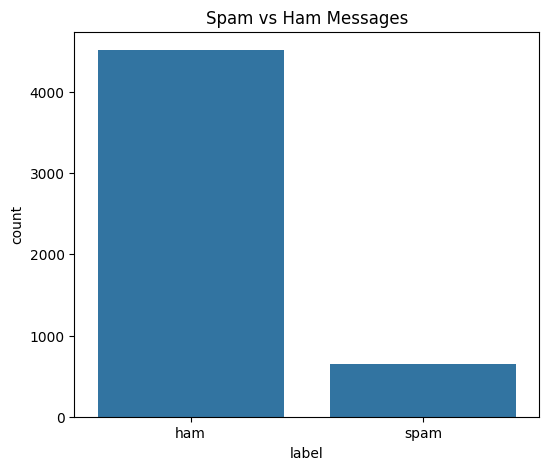

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="label",
    data=df
)

plt.title("Spam vs Ham Messages")

plt.show()

In [15]:
df["label_num"] = df["label"].map({
    "ham":0,
    "spam":1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [16]:
def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    text = " ".join(words)

    return text

In [17]:
df["clean_message"] = df["message"].apply(preprocess_text)

df.head()

,label,message,label_num,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,0,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,nah dont think goes usf lives around though


In [18]:
print("Original Message\n")
print(df["message"][0])

print("\nCleaned Message\n")
print(df["clean_message"][0])

Original Message

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned Message

go jurong point crazy available bugis n great world la e buffet cine got amore wat


# TF-IDF Vectorizer

TF-IDF stands for **Term Frequency–Inverse Document Frequency**.

It converts text into numerical values so machine learning algorithms can understand text.

- **Term Frequency (TF):** Measures how often a word appears in a document.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that appear in many documents.
- TF-IDF gives higher importance to words that are unique and meaningful while reducing the importance of common words.

This representation improves the performance of text classification models such as Naive Bayes and Logistic Regression.

In [19]:
X = df["clean_message"]

y = df["label_num"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(4135,)
(1034,)


In [21]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4135, 5000)
(1034, 5000)


In [22]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aah' 'aaniye' 'aathilove' 'aathiwhere' 'ab' 'abbey' 'abdomen' 'abeg'
 'abel' 'aberdeen' 'abi' 'ability' 'abiola' 'abj' 'able' 'abt' 'aburo'
 'ac' 'academic' 'acc' 'accept' 'access' 'accident' 'accidentally'
 'account' 'accounts' 'ache' 'aclpm' 'across' 'action' 'activate'
 'activities' 'actual' 'actually' 'ad' 'add' 'added' 'addicted' 'addie'
 'address' 'admin' 'admirer' 'adoring' 'adult' 'advance' 'advice' 'advise'
 'ae' 'affairs' 'affectionate']


In [23]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Multinomial Naive Bayes Model Trained Successfully!")

Multinomial Naive Bayes Model Trained Successfully!


In [24]:
nb_predictions = nb_model.predict(
    X_test_tfidf
)

nb_predictions[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [25]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions
)

nb_recall = recall_score(
    y_test,
    nb_predictions
)

nb_f1 = f1_score(
    y_test,
    nb_predictions
)

print("Accuracy :", nb_accuracy)
print("Precision :", nb_precision)
print("Recall :", nb_recall)
print("F1 Score :", nb_f1)

Accuracy : 0.9661508704061895
Precision : 0.9897959183673469
Recall : 0.7404580152671756
F1 Score : 0.8471615720524017


In [26]:
print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=["Ham","Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



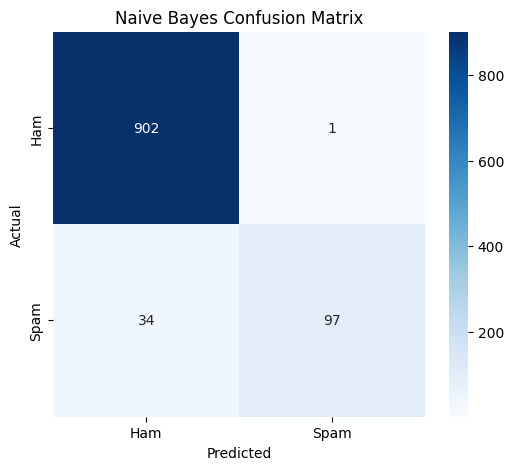

In [27]:
cm = confusion_matrix(
    y_test,
    nb_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [28]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression Trained Successfully!")

Logistic Regression Trained Successfully!


In [29]:
lr_predictions = lr_model.predict(
    X_test_tfidf
)

In [30]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions
)

lr_recall = recall_score(
    y_test,
    lr_predictions
)

lr_f1 = f1_score(
    y_test,
    lr_predictions
)

print("Accuracy :", lr_accuracy)

print("Precision :", lr_precision)

print("Recall :", lr_recall)

print("F1 Score :", lr_f1)

Accuracy : 0.9564796905222437
Precision : 0.9886363636363636
Recall : 0.6641221374045801
F1 Score : 0.7945205479452054


In [31]:
print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=["Ham","Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       903
        Spam       0.99      0.66      0.79       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.89      1034
weighted avg       0.96      0.96      0.95      1034



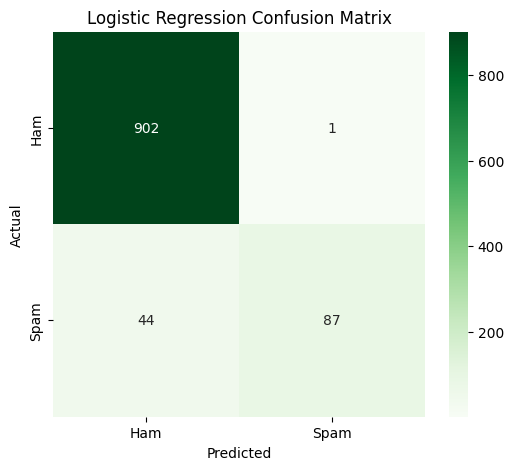

In [32]:
cm2 = confusion_matrix(
    y_test,
    lr_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [33]:
results = pd.DataFrame({

    "Model":[

        "Naive Bayes",

        "Logistic Regression"

    ],

    "Accuracy":[

        nb_accuracy,

        lr_accuracy

    ],

    "Precision":[

        nb_precision,

        lr_precision

    ],

    "Recall":[

        nb_recall,

        lr_recall

    ],

    "F1 Score":[

        nb_f1,

        lr_f1

    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.966151,0.989796,0.740458,0.847162
1,Logistic Regression,0.956480,0.988636,0.664122,0.794521


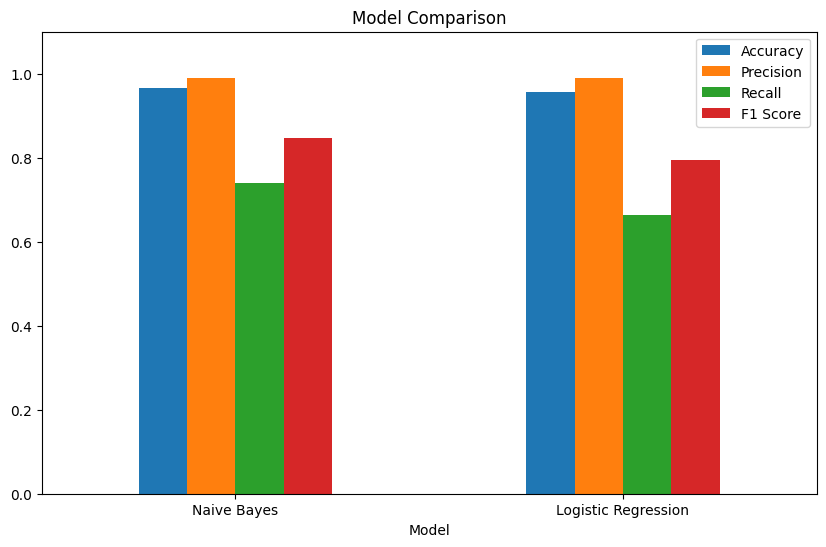

In [34]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")

plt.ylim(0,1.1)

plt.xticks(rotation=0)

plt.show()

In [36]:
if nb_f1 >= lr_f1:

    best_model = nb_model

    best_model_name = "Multinomial Naive Bayes"

else:

    best_model = lr_model

    best_model_name = "Logistic Regression"

print("Best Model :", best_model_name)

Best Model : Multinomial Naive Bayes


# Why is Recall Important?

Recall is especially important in spam detection because it measures how many actual spam messages are correctly identified.

A low recall means many spam messages are incorrectly classified as normal (ham), allowing unwanted or potentially harmful messages to reach the user's inbox.

Therefore, a spam detection system should aim for a high recall while maintaining good precision. The F1-score helps evaluate the balance between these two metrics.

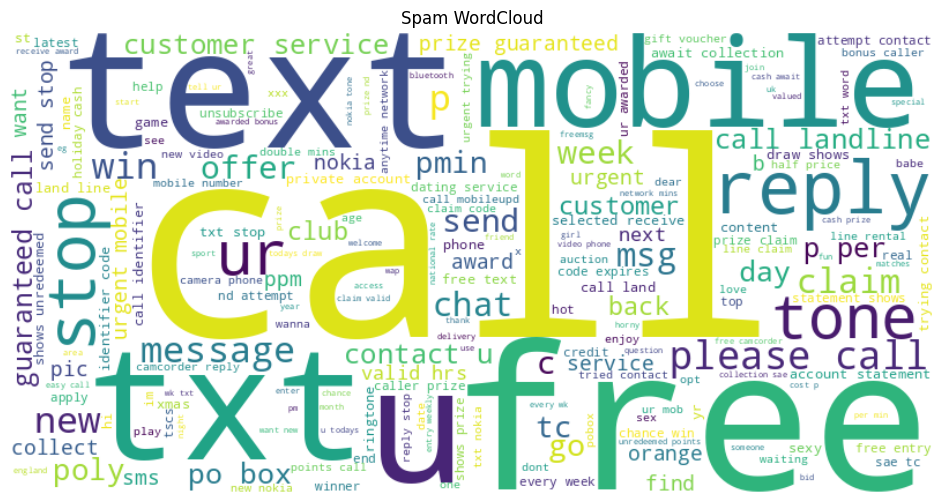

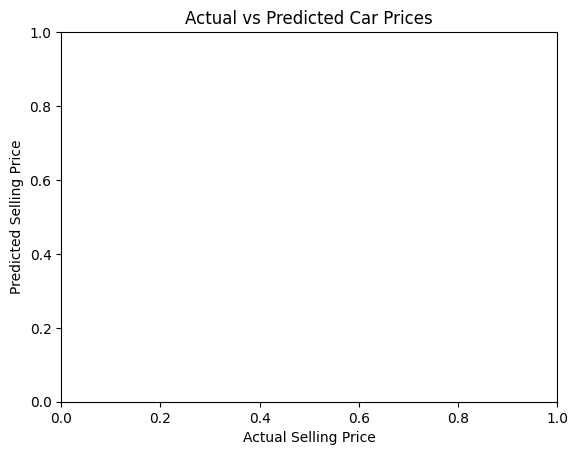

In [37]:
spam_text = " ".join(
    df[df["label"]=="spam"]["clean_message"]
)

spam_cloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(spam_text)

plt.figure(figsize=(12,6))

plt.imshow(
    spam_cloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Spam WordCloud")

plt.show()

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

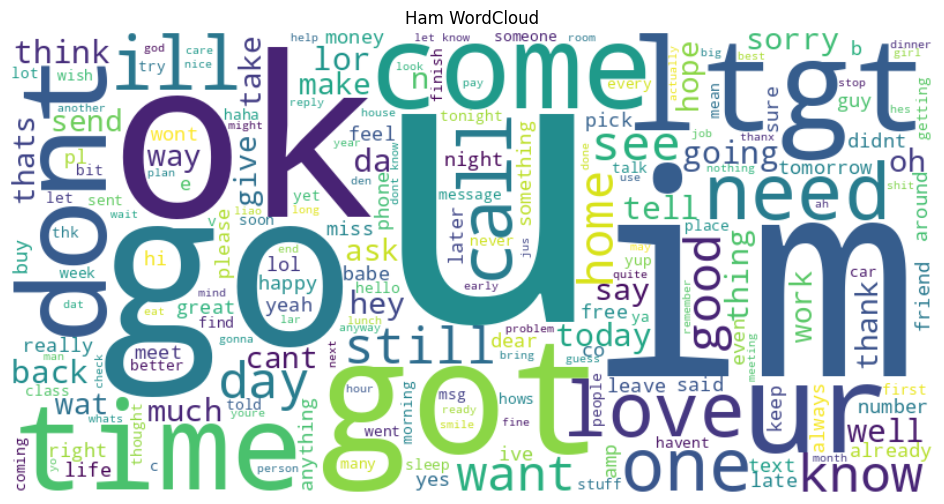

In [38]:
ham_text = " ".join(
    df[df["label"]=="ham"]["clean_message"]
)

ham_cloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(ham_text)

plt.figure(figsize=(12,6))

plt.imshow(
    ham_cloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Ham WordCloud")

plt.show()

In [39]:
message = "Congratulations! You won a FREE iPhone. Click here now."

cleaned = preprocess_text(message)

vector = tfidf.transform([cleaned])

prediction = best_model.predict(vector)

if prediction[0] == 1:
    print("Prediction : SPAM")
else:
    print("Prediction : HAM")

Prediction : SPAM


In [40]:
joblib.dump(
    best_model,
    "spam_detection_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("Files Saved Successfully!")

Files Saved Successfully!


In [41]:
from google.colab import files

files.download("spam_detection_model.pkl")

files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
loaded_model = joblib.load("car_price_model.pkl")

test_prediction = loaded_model.predict(X.iloc[[0]])

print("Prediction from saved model:", test_prediction[0])

Prediction from saved model: 178083.7380952381


In [ ]:
import joblib

model = joblib.load("car_price_model.pkl")

In [ ]:
print(X_train.shape)
print(X_test.shape)

(12244, 14)
(3062, 14)


In [ ]:
pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = pipeline.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 85213.93198310734
Root Mean Squared Error: 223986.51662889431
R² Score: 0.9359749963421131


In [ ]:
import joblib

joblib.dump(pipeline, "car_price_model.pkl")

print("car_price_model.pkl saved successfully!")

car_price_model.pkl saved successfully!


In [ ]:
from google.colab import files

files.download("car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>